Дорогой студент!

В данном домашнем задании предоставляется возможность поработать с задачей по распознаванию позитивных и негативных отзывы людей по автомобилю Tesla. База для обучения содержит два текстовых файла с рядом строчных отзывов с мнением людей об автомобиле Tesla, соответственно негативного и позитивного содержания. Ссылка на скачивание базы уже включена в ноутбук задания.


Необходимо выполнить следующие действия:

  1. Загрузите саму базу по ссылке и подговьте файлы базы для обработки.
  2. Создайте обучающую и проверочную выборки, обратив особое внимание на балансировку базы: количество примеров каждого класса должно быть примерно одного порядка.
  3. Подготовьте выборки для обучения и обучите сеть. Добейтесь результата точности сети в 85-90% на проверочной выборке.
   


**Импорт библиотек, загрузка базы и подготовка её к предобработке.**

In [1]:
# Работа с массивами данных
import numpy as np

# Работа с таблицами
import pandas as pd

# Отрисовка графиков
import matplotlib.pyplot as plt

# Функции-утилиты для работы с категориальными данными
from tensorflow.keras import utils

# Класс для конструирования последовательной модели нейронной сети
from tensorflow.keras.models import Sequential

# Основные слои
from tensorflow.keras.layers import Dense, Dropout, SpatialDropout1D, BatchNormalization, Embedding, Flatten, Activation

# Токенизатор для преобразование текстов в последовательности
from tensorflow.keras.preprocessing.text import Tokenizer

# Заполнение последовательностей до определенной длины
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Загрузка датасетов из облака google
import gdown

# Для работы с файлами в Colaboratory
import os

# Отрисовка графиков
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l7/tesla.zip', None, quiet=True)

'tesla.zip'

Деление общей базы отзывов на данные для обучения и проверки.

In [3]:
# Распаковка архива в папку writers
!unzip -qo tesla.zip -d tesla/

# Просмотр содержимого папки
!ls tesla

'Негативный отзыв.txt'	'Позитивный отзыв.txt'


Загрузка текста из файлов

In [4]:
# Функция чтения текстового файла
def read_text(file_name):
    # открываем файл
    with open(file_name, 'r') as f:
        # читаем весь текст и заменяем переносы строк пробелами
        text = f.read().replace("\n", " ")
    return text

# Список для хранения текстов
texts_list = []

# Читаем все файлы из папки
for j in os.listdir('/content/tesla/'):
    texts_list.append(read_text('/content/tesla/' + j))


# texts_list[0] — негатив
# texts_list[1] — позитив
class_names = ["Негатив", "Позитив"]


Разбиваем текст на окна

In [5]:
def split_text(text, win_size=100, step=100):
    # разбиваем текст на слова
    words = text.split()

    # формируем окна фиксированной длины
    return [
        ' '.join(words[i:i+win_size])   # собираем окно обратно в строку
        for i in range(0, len(words) - win_size, step)
        # step = win_size
    ]

all_chunks = []   # все фрагменты
all_labels = []   # соответствующие метки классов

# Проходим по каждому классу (негатив / позитив)
for cls in range(len(texts_list)):
    chunks = split_text(texts_list[cls])  # разбиваем текст на окна

    all_chunks += chunks                  # добавляем фрагменты
    all_labels += [cls] * len(chunks)     # добавляем метки

all_chunks = np.array(all_chunks)
all_labels = np.array(all_labels)


Разделение на train and val

In [6]:
from sklearn.model_selection import train_test_split
x_train, x_val, y_train, y_val = train_test_split(
    all_chunks,
    all_labels,
    test_size=0.2,
    random_state=42,
    stratify=all_labels# сохраняем баланс классов
)

print("До балансировки:", np.bincount(y_train))

До балансировки: [168 259]


Балансировка классов

In [7]:
min_count = min(np.bincount(y_train))

balanced_x = []
balanced_y = []

# проходим по каждому классу
for cls in np.unique(y_train):
    # выбираем только элементы текущего класса
    cls_x = x_train[y_train == cls][:min_count]

    balanced_x.extend(cls_x)
    balanced_y.extend([cls] * len(cls_x))

# обновляем train
x_train = np.array(balanced_x)
y_train = np.array(balanced_y)

print("После балансировки:", np.bincount(y_train))

После балансировки: [168 168]


Токенизация

In [8]:
VOCAB_SIZE = 10000

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='UNK')
tokenizer.fit_on_texts(x_train)
# преобразуем тексты в матрицы признаков
x_train = tokenizer.texts_to_matrix(x_train)
x_val   = tokenizer.texts_to_matrix(x_val)



Создание модели

In [9]:
model = Sequential()

model.add(Dense(128, input_dim=VOCAB_SIZE, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Обучение

In [10]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    x_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(x_val, y_val),
    callbacks=[early_stop]
)

Epoch 1/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.5387 - loss: 0.6882 - val_accuracy: 0.7850 - val_loss: 0.6499
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7946 - loss: 0.5604 - val_accuracy: 0.8411 - val_loss: 0.5686
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9375 - loss: 0.3809 - val_accuracy: 0.8785 - val_loss: 0.4529
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9732 - loss: 0.2058 - val_accuracy: 0.8785 - val_loss: 0.3480
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9970 - loss: 0.0789 - val_accuracy: 0.8972 - val_loss: 0.3149
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 1.0000 - loss: 0.0315 - val_accuracy: 0.8785 - val_loss: 0.2879
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9970 - loss: 0.0167 - val_accuracy: 0.8972 - val_loss: 0.3091
Epoch 8/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 1.0000 - loss: 0.0093 - val_accuracy: 0.8972 - v

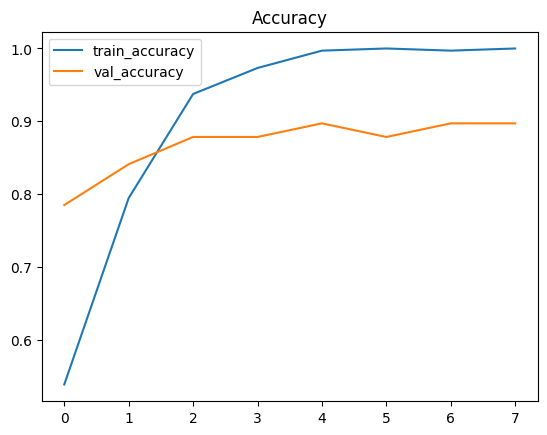

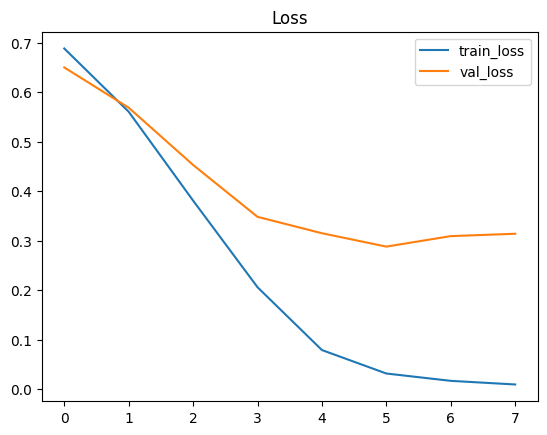

In [11]:
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.legend()
plt.title("Accuracy")
plt.show()

plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title("Loss")
plt.show()